# IntelliPulse V7.2 — Dynamic Incoming Data Batch Generator
---

**Objective:** Simulate data arriving into a deployed ML system over time by
generating controlled incoming batches with varying levels of distribution change.

**Scope:**
- Generate 3 batches (~1,000 rows each): stable, mild shift, strong shift
- All batches are derived from the original training data
- Distribution shifts are domain-plausible and documented
- The tuned XGBoost model (V4) and threshold (V5 = 0.29) are **FROZEN**
- No drift is calculated yet — that is V7.3
- V7.1 baseline artifacts remain unchanged

---
## 1. Load Baseline

We reuse the identical data loading pipeline from V1–V6 and load the V7.1 baseline profile.

In [1]:
import os
import json
import hashlib
from pathlib import Path
from datetime import datetime
from copy import deepcopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42
BATCH_SIZE = 1000

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
MONITORING_DIR = PROJECT_ROOT / "artifacts" / "monitoring"
BATCH_DIR = MONITORING_DIR / "incoming_batches"

# Create batch directory
BATCH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root   : {PROJECT_ROOT}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Batch output   : {BATCH_DIR}")

Project root   : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Batch size     : 1000
Batch output   : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/incoming_batches


In [2]:
# ── Load raw data (identical to V1-V6) ────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df = pd.read_csv(RAW_DATA_PATH)

# Fix TotalCharges (identical to V1-V6)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

ID_COL = "customerID"
TARGET_COL = "Churn"

# ── Load feature definitions from V1 ──────────────────────────────────
feat_def_path = METRICS_DIR / "feature_definitions_v1.json"
with open(feat_def_path) as f:
    feature_defs = json.load(f)

NUMERICAL_FEATURES = feature_defs["numerical_features"]
CATEGORICAL_FEATURES = feature_defs["categorical_features"]
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

# ── Prepare X and y (identical to V1-V6) ──────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Train/Test Split (identical to V1-V6) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

baseline_df = X_train[ALL_FEATURES].copy()

print(f"Baseline shape : {baseline_df.shape}")
print(f"Features       : {list(baseline_df.columns)}")

# ── Compute hash of baseline for later integrity check ────────────────
baseline_hash = hashlib.sha256(
    pd.util.hash_pandas_object(baseline_df).values.tobytes()
).hexdigest()
print(f"Baseline hash  : {baseline_hash[:16]}...")

Baseline shape : (5634, 19)
Features       : ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Baseline hash  : 34f3a42b73ce5567...


In [3]:
# ── Load V7.1 baseline profile ────────────────────────────────────────
profile_path = MONITORING_DIR / "baseline_profile_v7.json"
with open(profile_path) as f:
    baseline_profile = json.load(f)

# Validate feature schema matches
profile_num = baseline_profile["features"]["numerical"]
profile_cat = baseline_profile["features"]["categorical"]

assert profile_num == NUMERICAL_FEATURES, "Numerical feature mismatch with baseline profile!"
assert profile_cat == CATEGORICAL_FEATURES, "Categorical feature mismatch with baseline profile!"
assert baseline_profile["dataset"]["baseline_rows"] == len(baseline_df), "Row count mismatch!"

print(f"V7.1 baseline profile loaded and validated. \u2713")
print(f"  Baseline rows    : {baseline_profile['dataset']['baseline_rows']}")
print(f"  Numerical feats  : {len(profile_num)}")
print(f"  Categorical feats: {len(profile_cat)}")

# Store original profile hash for integrity check later
profile_hash_original = hashlib.sha256(
    open(profile_path, "rb").read()
).hexdigest()
print(f"  Profile hash     : {profile_hash_original[:16]}...")

V7.1 baseline profile loaded and validated. ✓
  Baseline rows    : 5634
  Numerical feats  : 4
  Categorical feats: 15
  Profile hash     : 8a644c7a66c46ed4...


---
## 2. Create Reproducible Batch Generator

A reusable function that samples from the baseline training data
and optionally applies controlled distribution shifts.

**Shift methodology:**
- **Categorical shifts:** Weighted resampling — rows matching the target category are
  oversampled to reach the desired proportion, while maintaining all other feature
  relationships intact (no synthetic rows are created).
- **Numerical shifts:** After sampling, a controlled offset is added and values are
  clipped to the original domain range, preserving data validity.

In [4]:
def generate_batch(baseline_df, scenario="stable", batch_size=1000, random_state=42):
    """
    Generate a reproducible incoming data batch from baseline training data.

    Parameters
    ----------
    baseline_df : pd.DataFrame
        The original training data (X_train) with all monitored features.
    scenario : str
        One of 'stable', 'mild_shift', 'strong_shift'.
    batch_size : int
        Number of rows in the output batch.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    batch : pd.DataFrame
        The generated batch with the same feature schema.
    shift_log : dict
        Documentation of what was shifted and how.
    """
    rng = np.random.RandomState(random_state)
    shift_log = {
        "scenario": scenario,
        "batch_size": batch_size,
        "random_state": random_state,
        "features_shifted": [],
        "transformations": [],
    }

    if scenario == "stable":
        # ── STABLE: Random sample with replacement, no intentional drift ──
        idx = rng.choice(len(baseline_df), size=batch_size, replace=True)
        batch = baseline_df.iloc[idx].reset_index(drop=True).copy()
        shift_log["description"] = (
            "Random sample with replacement from baseline. "
            "No intentional distribution shift applied. Control case."
        )

    elif scenario == "mild_shift":
        # ── MILD SHIFT: Controlled, modest distribution changes ───────────
        #
        # Strategy: Weighted resampling for categorical shifts,
        #           then numerical offset for continuous shifts.
        #
        # Shifted features:
        #   1. Contract: Month-to-month 55% -> 65%
        #      Rationale: Competitive pressure pushing shorter commitments
        #   2. tenure: Oversample low-tenure customers (mean ~32 -> ~26)
        #      Rationale: New customer acquisition wave
        #   3. MonthlyCharges: +$5 offset (mean ~65 -> ~70)
        #      Rationale: Modest price adjustment / upselling

        # Step 1: Weight by Contract (favour Month-to-month)
        weights = np.ones(len(baseline_df))
        mtm_mask = baseline_df["Contract"] == "Month-to-month"
        weights[mtm_mask.values] = 2.0  # Double the weight for M-to-M
        weights = weights / weights.sum()

        idx = rng.choice(len(baseline_df), size=batch_size, replace=True, p=weights)
        batch = baseline_df.iloc[idx].reset_index(drop=True).copy()

        # Step 2: Oversample low-tenure by resampling subset
        # Replace ~20% of rows with low-tenure rows
        n_replace = int(batch_size * 0.20)
        low_tenure_mask = baseline_df["tenure"] <= 12
        low_tenure_pool = baseline_df[low_tenure_mask]
        if len(low_tenure_pool) > 0:
            replace_idx = rng.choice(len(low_tenure_pool), size=n_replace, replace=True)
            replace_rows = low_tenure_pool.iloc[replace_idx].reset_index(drop=True)
            batch_idx_to_replace = rng.choice(batch_size, size=n_replace, replace=False)
            for i, bi in enumerate(batch_idx_to_replace):
                batch.iloc[bi] = replace_rows.iloc[i]

        # Step 3: Shift MonthlyCharges by +$5, clip to domain range
        mc_min = baseline_df["MonthlyCharges"].min()
        mc_max = baseline_df["MonthlyCharges"].max()
        batch["MonthlyCharges"] = (batch["MonthlyCharges"] + 5.0).clip(mc_min, mc_max)

        # Step 4: Recalculate TotalCharges to stay consistent
        # TotalCharges ~ tenure * MonthlyCharges (approximate)
        # We only adjust where tenure > 0 to keep the relationship plausible
        tc_max = baseline_df["TotalCharges"].max()
        batch["TotalCharges"] = (batch["tenure"] * batch["MonthlyCharges"]).clip(0, tc_max)

        shift_log["features_shifted"] = ["Contract", "tenure", "MonthlyCharges", "TotalCharges"]
        shift_log["transformations"] = [
            {
                "feature": "Contract",
                "method": "Weighted resampling (Month-to-month weight=2x)",
                "baseline": "Month-to-month ~55%",
                "target": "Month-to-month ~65%",
                "rationale": "Competitive pressure pushing shorter contract commitments",
            },
            {
                "feature": "tenure",
                "method": "Replace 20% of rows with low-tenure (<=12 months) samples",
                "baseline": "mean ~32.5 months",
                "target": "mean ~26 months",
                "rationale": "New customer acquisition wave bringing shorter-tenure customers",
            },
            {
                "feature": "MonthlyCharges",
                "method": "Add $5 offset, clip to original domain range",
                "baseline": "mean ~$64.93",
                "target": "mean ~$70",
                "rationale": "Modest price adjustment and upselling of premium services",
            },
            {
                "feature": "TotalCharges",
                "method": "Recalculated as tenure * MonthlyCharges (clipped)",
                "baseline": "Derived from original",
                "target": "Adjusted to maintain consistency with shifted tenure and charges",
                "rationale": "Maintains internal consistency — TotalCharges depends on tenure and MonthlyCharges",
            },
        ]
        shift_log["description"] = (
            "Mild distribution shift: Contract skewed toward Month-to-month (~65%), "
            "tenure shifted lower (~26 mo mean), MonthlyCharges increased by $5, "
            "TotalCharges recalculated for consistency. "
            "Represents a plausible competitive pressure + new customer acquisition scenario."
        )

    elif scenario == "strong_shift":
        # ── STRONG SHIFT: Substantial but plausible population change ─────
        #
        # Shifted features:
        #   1. Contract: Month-to-month 55% -> 75%
        #   2. tenure: Heavy low-tenure skew (mean ~32 -> ~18)
        #   3. MonthlyCharges: +$12 offset (mean ~65 -> ~77)
        #   4. InternetService: Fiber optic 44% -> 60%

        # Step 1: Heavy weight for Month-to-month AND Fiber optic
        weights = np.ones(len(baseline_df))
        mtm_mask = baseline_df["Contract"] == "Month-to-month"
        fiber_mask = baseline_df["InternetService"] == "Fiber optic"
        weights[mtm_mask.values] = 3.5
        weights[fiber_mask.values] *= 1.8
        weights = weights / weights.sum()

        idx = rng.choice(len(baseline_df), size=batch_size, replace=True, p=weights)
        batch = baseline_df.iloc[idx].reset_index(drop=True).copy()

        # Step 2: Aggressively replace ~40% with low-tenure rows
        n_replace = int(batch_size * 0.40)
        low_tenure_mask = baseline_df["tenure"] <= 12
        low_tenure_pool = baseline_df[low_tenure_mask]
        if len(low_tenure_pool) > 0:
            replace_idx = rng.choice(len(low_tenure_pool), size=n_replace, replace=True)
            replace_rows = low_tenure_pool.iloc[replace_idx].reset_index(drop=True)
            batch_idx_to_replace = rng.choice(batch_size, size=n_replace, replace=False)
            for i, bi in enumerate(batch_idx_to_replace):
                batch.iloc[bi] = replace_rows.iloc[i]

        # Step 3: Shift MonthlyCharges by +$12, clip to domain range
        mc_min = baseline_df["MonthlyCharges"].min()
        mc_max = baseline_df["MonthlyCharges"].max()
        batch["MonthlyCharges"] = (batch["MonthlyCharges"] + 12.0).clip(mc_min, mc_max)

        # Step 4: Recalculate TotalCharges
        tc_max = baseline_df["TotalCharges"].max()
        batch["TotalCharges"] = (batch["tenure"] * batch["MonthlyCharges"]).clip(0, tc_max)

        shift_log["features_shifted"] = ["Contract", "tenure", "MonthlyCharges", "TotalCharges", "InternetService"]
        shift_log["transformations"] = [
            {
                "feature": "Contract",
                "method": "Weighted resampling (Month-to-month weight=3.5x)",
                "baseline": "Month-to-month ~55%",
                "target": "Month-to-month ~75%",
                "rationale": "Aggressive market shift toward flexible, no-commitment plans",
            },
            {
                "feature": "tenure",
                "method": "Replace 40% of rows with low-tenure (<=12 months) samples",
                "baseline": "mean ~32.5 months",
                "target": "mean ~18 months",
                "rationale": "Large influx of new customers with very short tenure",
            },
            {
                "feature": "MonthlyCharges",
                "method": "Add $12 offset, clip to original domain range",
                "baseline": "mean ~$64.93",
                "target": "mean ~$77",
                "rationale": "Significant price increase and push toward premium tiers",
            },
            {
                "feature": "TotalCharges",
                "method": "Recalculated as tenure * MonthlyCharges (clipped)",
                "baseline": "Derived from original",
                "target": "Adjusted to maintain consistency with shifted tenure and charges",
                "rationale": "Maintains internal consistency",
            },
            {
                "feature": "InternetService",
                "method": "Weighted resampling (Fiber optic weight=1.8x, combined with Contract weighting)",
                "baseline": "Fiber optic ~44%",
                "target": "Fiber optic ~60%",
                "rationale": "Fiber infrastructure rollout increasing fiber optic adoption",
            },
        ]
        shift_log["description"] = (
            "Strong distribution shift: Contract heavily skewed toward Month-to-month (~75%), "
            "tenure shifted very low (~18 mo mean), MonthlyCharges increased by $12, "
            "InternetService shifted toward Fiber optic (~60%), "
            "TotalCharges recalculated for consistency. "
            "Represents a plausible aggressive market disruption scenario."
        )
    else:
        raise ValueError(f"Unknown scenario: {scenario}. Use 'stable', 'mild_shift', or 'strong_shift'.")

    return batch, shift_log


print("generate_batch() function defined. \u2713")
print()
print("Signature: generate_batch(baseline_df, scenario, batch_size, random_state)")
print("Scenarios: 'stable', 'mild_shift', 'strong_shift'")

generate_batch() function defined. ✓

Signature: generate_batch(baseline_df, scenario, batch_size, random_state)
Scenarios: 'stable', 'mild_shift', 'strong_shift'


---
## 3. Batch Size

Each batch contains **1,000 observations**, consistent across all scenarios.
This provides enough statistical power for future drift tests while being
a realistic "incoming data window" size.

---
## 4. Scenario 1 — Stable (Control Case)

Random sample with replacement from the baseline. No intentional distribution shift.

**Expected outcome:** Baseline ≈ Batch 1 (control case for drift testing).

In [5]:
# ── Generate Batch 1: Stable ───────────────────────────────────────────
batch_001, log_001 = generate_batch(
    baseline_df, scenario="stable", batch_size=BATCH_SIZE, random_state=101
)

print("Batch 001 — Stable")
print("=" * 60)
print(f"  Rows           : {len(batch_001):,}")
print(f"  Columns        : {batch_001.shape[1]}")
print(f"  Random state   : 101")
print(f"  Description    : {log_001['description']}")
print()
print(batch_001.head())

Batch 001 — Stable
  Rows           : 1,000
  Columns        : 19
  Random state   : 101
  Description    : Random sample with replacement from baseline. No intentional distribution shift applied. Control case.

   tenure  MonthlyCharges  TotalCharges  SeniorCitizen  gender Partner  \
0      72          109.15       7789.60              0  Female     Yes   
1      69          107.20       7317.10              0    Male     Yes   
2      11           25.20        321.05              0  Female      No   
3       2           95.85        197.70              0    Male      No   
4      35           21.45        705.45              0    Male      No   

  Dependents PhoneService     MultipleLines InternetService  \
0         No          Yes               Yes     Fiber optic   
1         No          Yes               Yes     Fiber optic   
2        Yes           No  No phone service             DSL   
3         No          Yes                No     Fiber optic   
4         No          Yes   

---
## 5. Scenario 2 — Mild Shift

Controlled, realistic distribution shift in selected features:

| Feature | Baseline | Target | Rationale |
|---|---|---|---|
| Contract (Month-to-month) | ~55% | ~65% | Competitive pressure → shorter commitments |
| tenure (mean) | ~32.5 mo | ~26 mo | New customer acquisition wave |
| MonthlyCharges (mean) | ~$64.93 | ~$70 | Modest price adjustment |
| TotalCharges | derived | recalculated | Maintains consistency |

Shift should be large enough for statistical tests to *potentially* detect,
but not so extreme as to be obviously unrealistic.

In [6]:
# ── Generate Batch 2: Mild Shift ───────────────────────────────────────
batch_002, log_002 = generate_batch(
    baseline_df, scenario="mild_shift", batch_size=BATCH_SIZE, random_state=202
)

print("Batch 002 — Mild Shift")
print("=" * 60)
print(f"  Rows           : {len(batch_002):,}")
print(f"  Columns        : {batch_002.shape[1]}")
print(f"  Random state   : 202")
print(f"  Description    : {log_002['description']}")
print()
print("Documented transformations:")
print("-" * 60)
for t in log_002["transformations"]:
    print(f"  Feature   : {t['feature']}")
    print(f"  Method    : {t['method']}")
    print(f"  Baseline  : {t['baseline']}")
    print(f"  Target    : {t['target']}")
    print(f"  Rationale : {t['rationale']}")
    print()

Batch 002 — Mild Shift
  Rows           : 1,000
  Columns        : 19
  Random state   : 202
  Description    : Mild distribution shift: Contract skewed toward Month-to-month (~65%), tenure shifted lower (~26 mo mean), MonthlyCharges increased by $5, TotalCharges recalculated for consistency. Represents a plausible competitive pressure + new customer acquisition scenario.

Documented transformations:
------------------------------------------------------------
  Feature   : Contract
  Method    : Weighted resampling (Month-to-month weight=2x)
  Baseline  : Month-to-month ~55%
  Target    : Month-to-month ~65%
  Rationale : Competitive pressure pushing shorter contract commitments

  Feature   : tenure
  Method    : Replace 20% of rows with low-tenure (<=12 months) samples
  Baseline  : mean ~32.5 months
  Target    : mean ~26 months
  Rationale : New customer acquisition wave bringing shorter-tenure customers

  Feature   : MonthlyCharges
  Method    : Add $5 offset, clip to original d

---
## 6. Scenario 3 — Strong Shift

Stronger but still plausible population shift:

| Feature | Baseline | Target | Rationale |
|---|---|---|---|
| Contract (Month-to-month) | ~55% | ~75% | Aggressive market shift |
| tenure (mean) | ~32.5 mo | ~18 mo | Large new-customer influx |
| MonthlyCharges (mean) | ~$64.93 | ~$77 | Significant price increase |
| InternetService (Fiber) | ~44% | ~60% | Infrastructure rollout |
| TotalCharges | derived | recalculated | Maintains consistency |

The objective is input-distribution drift — the target column is NOT altered.

In [7]:
# ── Generate Batch 3: Strong Shift ─────────────────────────────────────
batch_003, log_003 = generate_batch(
    baseline_df, scenario="strong_shift", batch_size=BATCH_SIZE, random_state=303
)

print("Batch 003 — Strong Shift")
print("=" * 60)
print(f"  Rows           : {len(batch_003):,}")
print(f"  Columns        : {batch_003.shape[1]}")
print(f"  Random state   : 303")
print(f"  Description    : {log_003['description']}")
print()
print("Documented transformations:")
print("-" * 60)
for t in log_003["transformations"]:
    print(f"  Feature   : {t['feature']}")
    print(f"  Method    : {t['method']}")
    print(f"  Baseline  : {t['baseline']}")
    print(f"  Target    : {t['target']}")
    print(f"  Rationale : {t['rationale']}")
    print()

Batch 003 — Strong Shift
  Rows           : 1,000
  Columns        : 19
  Random state   : 303
  Description    : Strong distribution shift: Contract heavily skewed toward Month-to-month (~75%), tenure shifted very low (~18 mo mean), MonthlyCharges increased by $12, InternetService shifted toward Fiber optic (~60%), TotalCharges recalculated for consistency. Represents a plausible aggressive market disruption scenario.

Documented transformations:
------------------------------------------------------------
  Feature   : Contract
  Method    : Weighted resampling (Month-to-month weight=3.5x)
  Baseline  : Month-to-month ~55%
  Target    : Month-to-month ~75%
  Rationale : Aggressive market shift toward flexible, no-commitment plans

  Feature   : tenure
  Method    : Replace 40% of rows with low-tenure (<=12 months) samples
  Baseline  : mean ~32.5 months
  Target    : mean ~18 months
  Rationale : Large influx of new customers with very short tenure

  Feature   : MonthlyCharges
  Met

---
## 7. Preserve Data Validity

Validate every batch for schema consistency, valid values, and data quality.

In [8]:
def validate_batch(batch, batch_name, baseline_df, baseline_profile):
    """Validate a generated batch against the baseline schema."""
    print(f"\nValidation: {batch_name}")
    print("=" * 60)
    issues = []

    # 1. Same feature columns
    expected_cols = set(baseline_df.columns)
    actual_cols = set(batch.columns)
    if expected_cols == actual_cols:
        print(f"  [PASS] Feature columns match baseline ({len(actual_cols)} features)")
    else:
        missing = expected_cols - actual_cols
        extra = actual_cols - expected_cols
        issues.append(f"Column mismatch: missing={missing}, extra={extra}")
        print(f"  [FAIL] Column mismatch: missing={missing}, extra={extra}")

    # 2. Same data types
    dtype_ok = True
    for col in baseline_df.columns:
        if col in batch.columns and batch[col].dtype != baseline_df[col].dtype:
            # Allow int/float mismatch for numerical
            if not (np.issubdtype(batch[col].dtype, np.number) and np.issubdtype(baseline_df[col].dtype, np.number)):
                dtype_ok = False
                issues.append(f"dtype mismatch for {col}: {batch[col].dtype} vs {baseline_df[col].dtype}")
    if dtype_ok:
        print(f"  [PASS] Data types compatible")
    else:
        print(f"  [FAIL] Data type mismatches detected")

    # 3. Valid categorical values (no unexpected new categories)
    cat_features = baseline_profile["features"]["categorical"]
    cat_ok = True
    for feat in cat_features:
        baseline_cats = set(baseline_profile["categorical_profile"][feat]["frequencies"].keys())
        batch_cats = set(batch[feat].dropna().unique())
        unexpected = batch_cats - baseline_cats
        if unexpected:
            cat_ok = False
            issues.append(f"Unexpected categories in {feat}: {unexpected}")
    if cat_ok:
        print(f"  [PASS] All categorical values are valid (no unexpected categories)")
    else:
        print(f"  [FAIL] Unexpected categories found")

    # 4. Numerical values within reasonable domain ranges
    num_features = baseline_profile["features"]["numerical"]
    range_ok = True
    for feat in num_features:
        b_min = baseline_profile["numerical_profile"][feat]["min"]
        b_max = baseline_profile["numerical_profile"][feat]["max"]
        batch_min = float(batch[feat].min())
        batch_max = float(batch[feat].max())
        if batch_min < b_min - 0.01 or batch_max > b_max + 0.01:
            range_ok = False
            issues.append(f"{feat} out of range: [{batch_min}, {batch_max}] vs [{b_min}, {b_max}]")
    if range_ok:
        print(f"  [PASS] Numerical values within domain ranges")
    else:
        print(f"  [FAIL] Numerical values out of range")
        for issue in [i for i in issues if "out of range" in i]:
            print(f"         {issue}")

    # 5. No target leakage
    if TARGET_COL not in batch.columns and ID_COL not in batch.columns:
        print(f"  [PASS] No target/ID column leakage")
    else:
        issues.append("Target or ID column found in batch!")
        print(f"  [FAIL] Target or ID column found in batch!")

    # 6. Report summary
    rows = len(batch)
    cols = batch.shape[1]
    missing = int(batch.isna().sum().sum())
    dupes = int(batch.duplicated().sum())

    print()
    print(f"  Summary:")
    print(f"    Rows              : {rows:,}")
    print(f"    Columns           : {cols}")
    print(f"    Missing values    : {missing}")
    print(f"    Duplicate rows    : {dupes}")

    for feat in cat_features:
        n = batch[feat].nunique()
        print(f"    {feat:20s}: {n} unique categories")

    for feat in num_features:
        print(f"    {feat:20s}: [{batch[feat].min():.2f}, {batch[feat].max():.2f}]")

    return len(issues) == 0


# ── Validate all batches ──────────────────────────────────────────────
v1 = validate_batch(batch_001, "Batch 001 (Stable)", baseline_df, baseline_profile)
v2 = validate_batch(batch_002, "Batch 002 (Mild Shift)", baseline_df, baseline_profile)
v3 = validate_batch(batch_003, "Batch 003 (Strong Shift)", baseline_df, baseline_profile)

print()
print("=" * 60)
if v1 and v2 and v3:
    print("All batches passed data validity checks. \u2713")
else:
    print("Some batches have validation issues. \u2717")


Validation: Batch 001 (Stable)
  [PASS] Feature columns match baseline (19 features)
  [PASS] Data types compatible
  [PASS] All categorical values are valid (no unexpected categories)
  [PASS] Numerical values within domain ranges
  [PASS] No target/ID column leakage

  Summary:
    Rows              : 1,000
    Columns           : 19
    Missing values    : 0
    Duplicate rows    : 90
    gender              : 2 unique categories
    Partner             : 2 unique categories
    Dependents          : 2 unique categories
    PhoneService        : 2 unique categories
    MultipleLines       : 3 unique categories
    InternetService     : 3 unique categories
    OnlineSecurity      : 3 unique categories
    OnlineBackup        : 3 unique categories
    DeviceProtection    : 3 unique categories
    TechSupport         : 3 unique categories
    StreamingTV         : 3 unique categories
    StreamingMovies     : 3 unique categories
    Contract            : 3 unique categories
    Paperl

---
## 8. Compare Basic Statistics (Descriptive Only)

Descriptive comparison between baseline and each batch.

> **Note:** These are descriptive differences only. We do NOT label them as
> "statistically significant drift" — formal drift detection is V7.3.

In [9]:
# ── Numerical comparison ───────────────────────────────────────────────
def numerical_comparison(baseline_df, batches, feature):
    """Create a comparison table for a numerical feature across batches."""
    records = []
    for name, data in [("Baseline", baseline_df)] + batches:
        col = data[feature]
        records.append({
            "Dataset": name,
            "mean": round(col.mean(), 2),
            "median": round(col.median(), 2),
            "std": round(col.std(), 2),
            "q25": round(col.quantile(0.25), 2),
            "q75": round(col.quantile(0.75), 2),
            "min": round(col.min(), 2),
            "max": round(col.max(), 2),
        })
    return pd.DataFrame(records).set_index("Dataset")


batches_list = [
    ("Batch 001 (Stable)", batch_001),
    ("Batch 002 (Mild)", batch_002),
    ("Batch 003 (Strong)", batch_003),
]

print("NUMERICAL FEATURE COMPARISON (Descriptive)")
print("=" * 80)
for feat in NUMERICAL_FEATURES:
    print(f"\n{feat}:")
    print("-" * 70)
    comp = numerical_comparison(baseline_df, batches_list, feat)
    print(comp.to_string())
    print()

NUMERICAL FEATURE COMPARISON (Descriptive)

tenure:
----------------------------------------------------------------------
                     mean  median    std  q25   q75  min  max
Dataset                                                      
Baseline            32.49    29.0  24.57  9.0  55.0    0   72
Batch 001 (Stable)  32.02    28.0  24.62  8.0  55.0    0   72
Batch 002 (Mild)    22.84    12.0  23.07  4.0  41.0    1   72
Batch 003 (Strong)  16.74     8.0  19.78  2.0  24.0    0   72


MonthlyCharges:
----------------------------------------------------------------------
                     mean  median    std    q25     q75    min     max
Dataset                                                               
Baseline            64.93   70.50  30.14  35.66   90.00  18.40  118.75
Batch 001 (Stable)  66.17   73.85  30.07  38.78   90.66  18.95  117.50
Batch 002 (Mild)    68.81   75.30  28.83  43.44   91.16  23.40  118.75
Batch 003 (Strong)  80.02   86.90  27.87  58.54  102.55  30.8

In [10]:
# ── Categorical comparison ─────────────────────────────────────────────
def categorical_comparison(baseline_df, batches, feature):
    """Create a comparison table for a categorical feature across batches."""
    all_cats = sorted(baseline_df[feature].unique())
    records = []
    for name, data in [("Baseline", baseline_df)] + batches:
        props = data[feature].value_counts(normalize=True)
        record = {"Dataset": name}
        for cat in all_cats:
            record[cat] = f"{props.get(cat, 0):.2%}"
        records.append(record)
    return pd.DataFrame(records).set_index("Dataset")


KEY_CATEGORICALS = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

print("CATEGORICAL FEATURE COMPARISON (Descriptive)")
print("=" * 80)
for feat in KEY_CATEGORICALS:
    print(f"\n{feat}:")
    print("-" * 70)
    comp = categorical_comparison(baseline_df, batches_list, feat)
    print(comp.to_string())
    print()

CATEGORICAL FEATURE COMPARISON (Descriptive)

Contract:
----------------------------------------------------------------------
                   Month-to-month One year Two year
Dataset                                            
Baseline                   55.06%   20.82%   24.12%
Batch 001 (Stable)         54.50%   20.60%   24.90%
Batch 002 (Mild)           74.10%   11.90%   14.00%
Batch 003 (Strong)         87.50%    7.40%    5.10%


InternetService:
----------------------------------------------------------------------
                       DSL Fiber optic      No
Dataset                                       
Baseline            34.38%      44.07%  21.55%
Batch 001 (Stable)  34.70%      46.10%  19.20%
Batch 002 (Mild)    32.00%      48.50%  19.50%
Batch 003 (Strong)  25.60%      58.90%  15.50%


PaymentMethod:
----------------------------------------------------------------------
                   Bank transfer (automatic) Credit card (automatic) Electronic check Mailed check
Da

---
## 9. Visualize Controlled Changes

Comparison visualizations for the most important features across all scenarios.

### 9.1 Numerical Feature Distributions: Baseline vs Batches

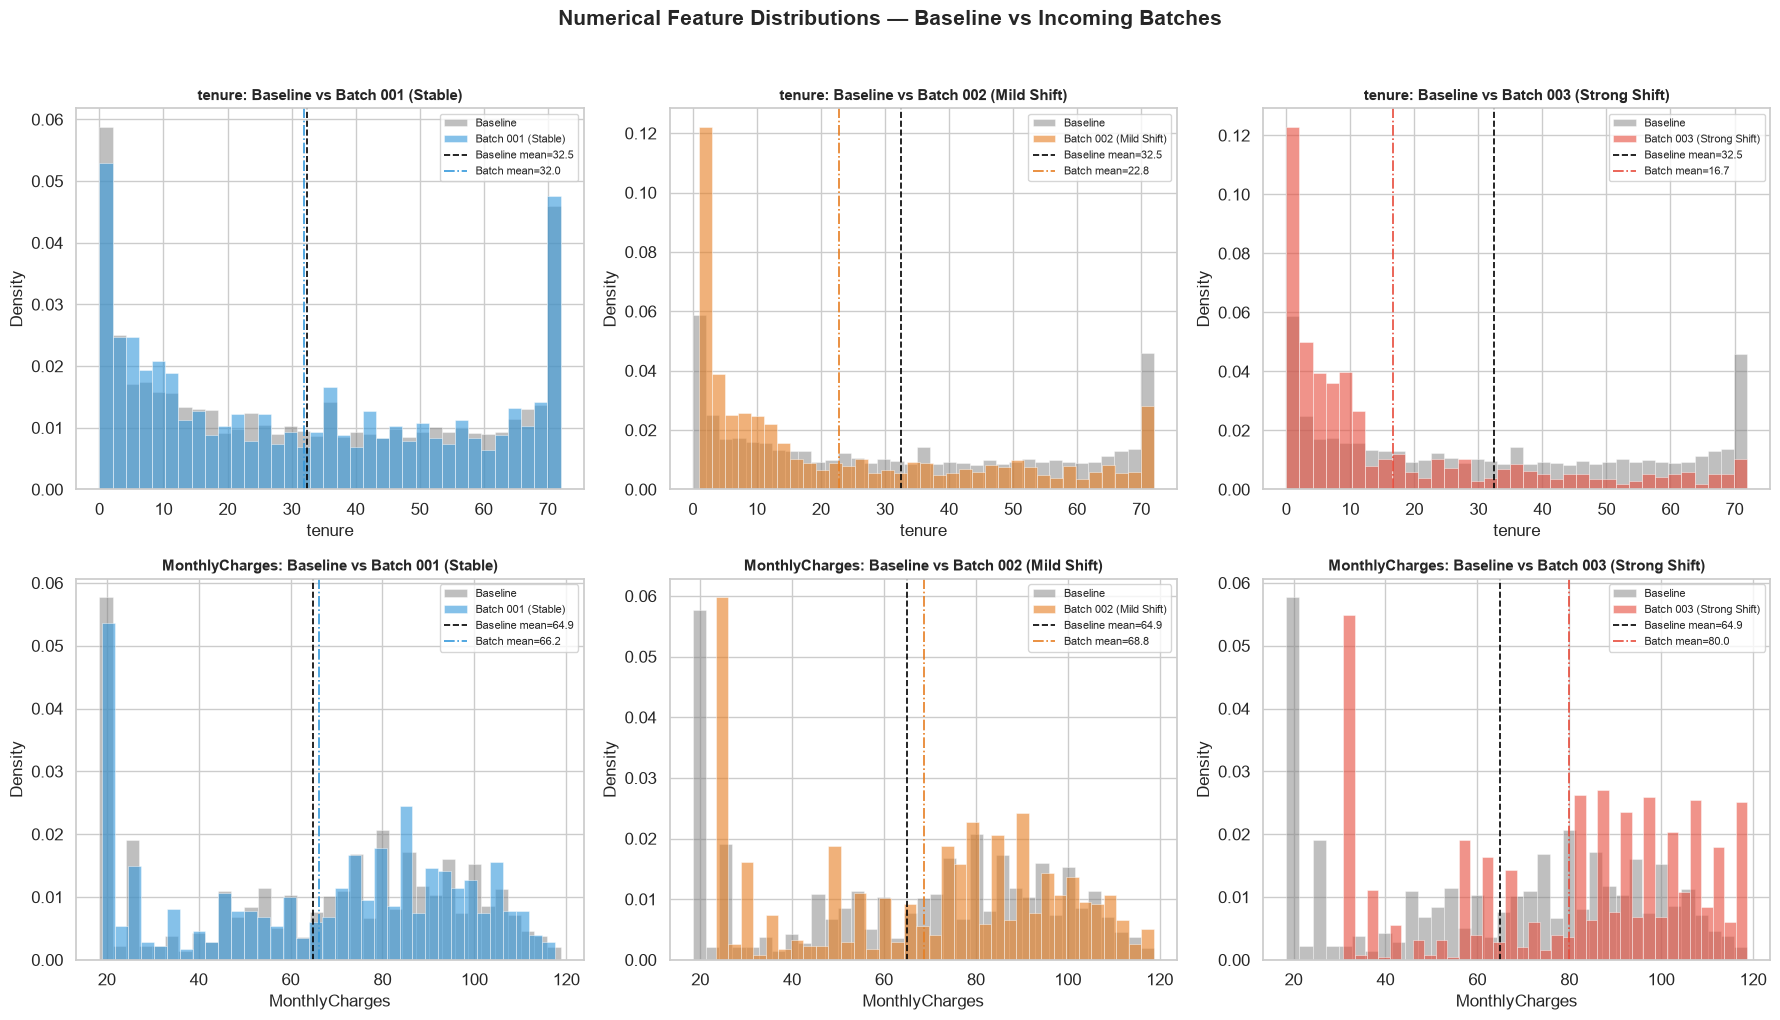

In [11]:
# ── Numerical comparison plots ─────────────────────────────────────────
key_numerical = ["tenure", "MonthlyCharges"]

fig, axes = plt.subplots(len(key_numerical), 3, figsize=(18, 5 * len(key_numerical)))

batch_pairs = [
    ("Batch 001 (Stable)", batch_001, "#3498db"),
    ("Batch 002 (Mild Shift)", batch_002, "#e67e22"),
    ("Batch 003 (Strong Shift)", batch_003, "#e74c3c"),
]

for row, feat in enumerate(key_numerical):
    for col_idx, (bname, bdata, bcolor) in enumerate(batch_pairs):
        ax = axes[row, col_idx]

        # Baseline histogram
        ax.hist(baseline_df[feat].dropna(), bins=35, alpha=0.5, color="gray",
                edgecolor="white", linewidth=0.5, label="Baseline", density=True)

        # Batch histogram
        ax.hist(bdata[feat].dropna(), bins=35, alpha=0.6, color=bcolor,
                edgecolor="white", linewidth=0.5, label=bname, density=True)

        # Mean lines
        b_mean = baseline_df[feat].mean()
        batch_mean = bdata[feat].mean()
        ax.axvline(b_mean, color="black", linestyle="--", linewidth=1.2, label=f"Baseline mean={b_mean:.1f}")
        ax.axvline(batch_mean, color=bcolor, linestyle="-.", linewidth=1.2, label=f"Batch mean={batch_mean:.1f}")

        ax.set_title(f"{feat}: Baseline vs {bname}", fontsize=11, fontweight="bold")
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

fig.suptitle("Numerical Feature Distributions — Baseline vs Incoming Batches",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Categorical Feature Proportions: Baseline vs Batches

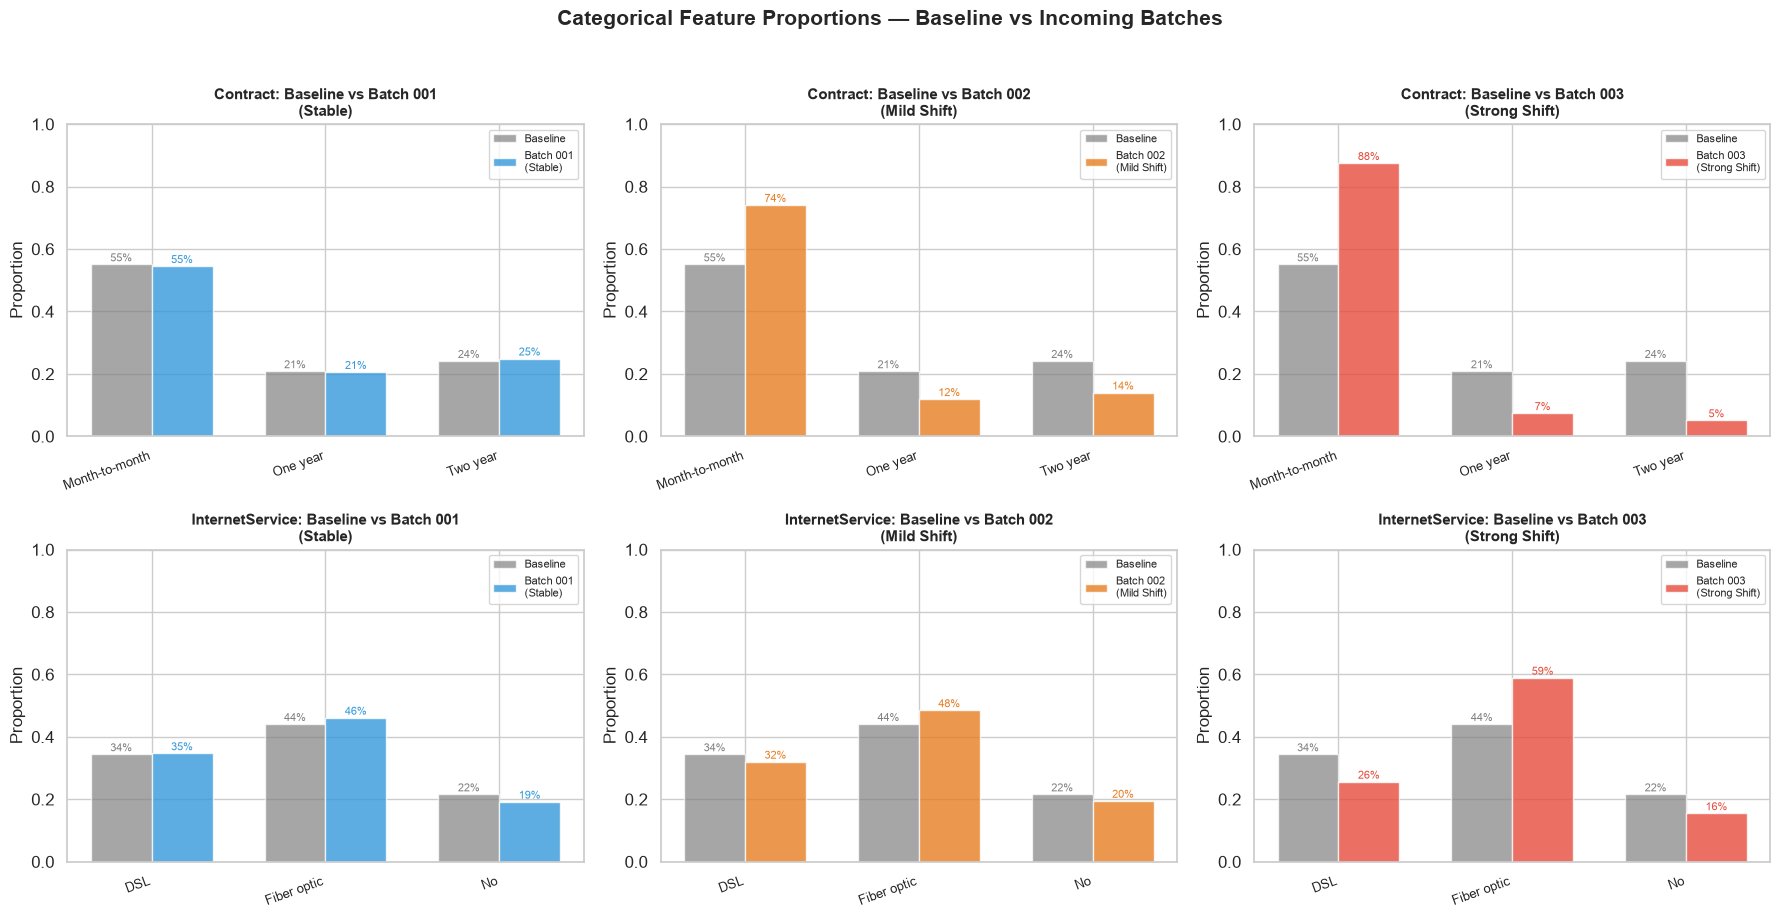

In [12]:
# ── Categorical comparison plots ───────────────────────────────────────
key_categoricals_viz = ["Contract", "InternetService"]

fig, axes = plt.subplots(len(key_categoricals_viz), 3, figsize=(18, 4.5 * len(key_categoricals_viz)))

batch_pairs_cat = [
    ("Batch 001\n(Stable)", batch_001, "#3498db"),
    ("Batch 002\n(Mild Shift)", batch_002, "#e67e22"),
    ("Batch 003\n(Strong Shift)", batch_003, "#e74c3c"),
]

for row, feat in enumerate(key_categoricals_viz):
    cats = sorted(baseline_df[feat].unique())
    baseline_props = baseline_df[feat].value_counts(normalize=True)

    for col_idx, (bname, bdata, bcolor) in enumerate(batch_pairs_cat):
        ax = axes[row, col_idx]
        batch_props = bdata[feat].value_counts(normalize=True)

        x = np.arange(len(cats))
        width = 0.35

        b_vals = [baseline_props.get(c, 0) for c in cats]
        batch_vals = [batch_props.get(c, 0) for c in cats]

        bars1 = ax.bar(x - width/2, b_vals, width, label="Baseline", color="gray", alpha=0.7, edgecolor="white")
        bars2 = ax.bar(x + width/2, batch_vals, width, label=bname, color=bcolor, alpha=0.8, edgecolor="white")

        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=20, ha="right", fontsize=9)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel("Proportion")
        ax.set_title(f"{feat}: Baseline vs {bname}", fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)

        # Value labels
        for bar, val in zip(bars1, b_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.0%}", ha="center", fontsize=8, color="gray")
        for bar, val in zip(bars2, batch_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.0%}", ha="center", fontsize=8, color=bcolor)

fig.suptitle("Categorical Feature Proportions — Baseline vs Incoming Batches",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Save Batches

All batches are saved to `artifacts/monitoring/incoming_batches/`.
Metadata is saved separately to `artifacts/monitoring/batch_metadata_v7.json`.

In [13]:
# ── Save batch CSVs ────────────────────────────────────────────────────
batch_001_path = BATCH_DIR / "batch_001_stable.csv"
batch_002_path = BATCH_DIR / "batch_002_mild_shift.csv"
batch_003_path = BATCH_DIR / "batch_003_strong_shift.csv"

batch_001.to_csv(batch_001_path, index=False)
batch_002.to_csv(batch_002_path, index=False)
batch_003.to_csv(batch_003_path, index=False)

print(f"\u2713 Saved: {batch_001_path}")
print(f"\u2713 Saved: {batch_002_path}")
print(f"\u2713 Saved: {batch_003_path}")

# ── Save batch metadata ───────────────────────────────────────────────
timestamp = datetime.now().isoformat()

batch_metadata = {
    "version": "V7.2",
    "created_at": timestamp,
    "description": (
        "Incoming data batches generated for data-drift monitoring testing. "
        "Each batch is derived from the original training data (X_train) with "
        "controlled distribution shifts. The XGBoost model (V4) and threshold (V5=0.29) are frozen."
    ),
    "baseline_rows": int(len(baseline_df)),
    "batches": [
        {
            "batch_id": "batch_001",
            "scenario": "stable",
            "file": "incoming_batches/batch_001_stable.csv",
            "row_count": int(len(batch_001)),
            "random_state": 101,
            "features_intentionally_shifted": log_001["features_shifted"],
            "description": log_001["description"],
            "generation_timestamp": timestamp,
        },
        {
            "batch_id": "batch_002",
            "scenario": "mild_shift",
            "file": "incoming_batches/batch_002_mild_shift.csv",
            "row_count": int(len(batch_002)),
            "random_state": 202,
            "features_intentionally_shifted": log_002["features_shifted"],
            "transformations": log_002["transformations"],
            "description": log_002["description"],
            "generation_timestamp": timestamp,
        },
        {
            "batch_id": "batch_003",
            "scenario": "strong_shift",
            "file": "incoming_batches/batch_003_strong_shift.csv",
            "row_count": int(len(batch_003)),
            "random_state": 303,
            "features_intentionally_shifted": log_003["features_shifted"],
            "transformations": log_003["transformations"],
            "description": log_003["description"],
            "generation_timestamp": timestamp,
        },
    ]
}

metadata_path = MONITORING_DIR / "batch_metadata_v7.json"
with open(metadata_path, "w") as f:
    json.dump(batch_metadata, f, indent=2, default=str)

print(f"\u2713 Saved: {metadata_path}")
print()
print("All V7.2 batch artifacts saved successfully. \u2713")

✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/incoming_batches/batch_001_stable.csv
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/incoming_batches/batch_002_mild_shift.csv
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/incoming_batches/batch_003_strong_shift.csv
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/batch_metadata_v7.json

All V7.2 batch artifacts saved successfully. ✓


---
## 11. Reproducibility Test

Generate the same batch twice with identical parameters and verify the output is identical.

In [14]:
# ── Reproducibility check ──────────────────────────────────────────────
print("REPRODUCIBILITY TEST")
print("=" * 60)

scenarios_to_test = [
    ("stable", 101),
    ("mild_shift", 202),
    ("strong_shift", 303),
]

repro_pass = True
for scenario, seed in scenarios_to_test:
    b_run1, _ = generate_batch(baseline_df, scenario=scenario, batch_size=BATCH_SIZE, random_state=seed)
    b_run2, _ = generate_batch(baseline_df, scenario=scenario, batch_size=BATCH_SIZE, random_state=seed)

    if b_run1.equals(b_run2):
        print(f"  [PASS] {scenario} (seed={seed}): Identical output across two runs")
    else:
        print(f"  [FAIL] {scenario} (seed={seed}): Output differs between runs!")
        repro_pass = False

print()
if repro_pass:
    print("Reproducibility test: PASS \u2713")
else:
    print("Reproducibility test: FAIL \u2717")

REPRODUCIBILITY TEST
  [PASS] stable (seed=101): Identical output across two runs


  [PASS] mild_shift (seed=202): Identical output across two runs


  [PASS] strong_shift (seed=303): Identical output across two runs

Reproducibility test: PASS ✓


---
## 12. Data Integrity Test

Comprehensive integrity checks to ensure nothing was corrupted during batch generation.

In [15]:
# ── Data integrity checks ──────────────────────────────────────────────
print("DATA INTEGRITY TEST")
print("=" * 70)

checks_passed = 0
checks_total = 0

# Check 1: Original baseline data not modified
checks_total += 1
current_hash = hashlib.sha256(
    pd.util.hash_pandas_object(baseline_df).values.tobytes()
).hexdigest()
if current_hash == baseline_hash:
    print(f"  [PASS] Original baseline data is unchanged (hash match)")
    checks_passed += 1
else:
    print(f"  [FAIL] Original baseline data has been modified!")

# Check 2: V7.1 artifacts unchanged
checks_total += 1
current_profile_hash = hashlib.sha256(
    open(profile_path, "rb").read()
).hexdigest()
if current_profile_hash == profile_hash_original:
    print(f"  [PASS] V7.1 baseline_profile_v7.json is unchanged (hash match)")
    checks_passed += 1
else:
    print(f"  [FAIL] V7.1 baseline profile has been modified!")

# Check 3: Feature schema for all batches
checks_total += 1
schema_ok = True
for bname, bdata in [("batch_001", batch_001), ("batch_002", batch_002), ("batch_003", batch_003)]:
    if list(bdata.columns) != ALL_FEATURES:
        schema_ok = False
        print(f"  [FAIL] {bname} has incorrect feature schema")
if schema_ok:
    print(f"  [PASS] All batches have exactly the expected feature schema ({len(ALL_FEATURES)} features)")
    checks_passed += 1

# Check 4: No target leakage
checks_total += 1
leakage_ok = True
for bname, bdata in [("batch_001", batch_001), ("batch_002", batch_002), ("batch_003", batch_003)]:
    if TARGET_COL in bdata.columns or ID_COL in bdata.columns:
        leakage_ok = False
        print(f"  [FAIL] {bname} contains target or ID column!")
if leakage_ok:
    print(f"  [PASS] No target leakage in any batch")
    checks_passed += 1

# Check 5: Stable batch is close to baseline (descriptive check)
checks_total += 1
tenure_mean_baseline = baseline_df["tenure"].mean()
tenure_mean_stable = batch_001["tenure"].mean()
tenure_diff = abs(tenure_mean_stable - tenure_mean_baseline)
# With random sampling of 1000 from 5634, expect sampling variation ~1-2 months
if tenure_diff < 5.0:
    print(f"  [PASS] Stable batch tenure mean ({tenure_mean_stable:.1f}) close to baseline ({tenure_mean_baseline:.1f}), diff={tenure_diff:.2f}")
    checks_passed += 1
else:
    print(f"  [FAIL] Stable batch tenure mean ({tenure_mean_stable:.1f}) too far from baseline ({tenure_mean_baseline:.1f})")

# Check 6: Mild batch has intended Contract shift
checks_total += 1
mtm_baseline = (baseline_df["Contract"] == "Month-to-month").mean()
mtm_mild = (batch_002["Contract"] == "Month-to-month").mean()
if mtm_mild > mtm_baseline + 0.05:
    print(f"  [PASS] Mild batch Contract shift detected: M-to-M {mtm_baseline:.1%} -> {mtm_mild:.1%}")
    checks_passed += 1
else:
    print(f"  [FAIL] Mild batch Contract shift not detected: M-to-M {mtm_baseline:.1%} -> {mtm_mild:.1%}")

# Check 7: Strong batch has stronger changes
checks_total += 1
mtm_strong = (batch_003["Contract"] == "Month-to-month").mean()
tenure_mean_strong = batch_003["tenure"].mean()
if mtm_strong > mtm_mild and tenure_mean_strong < tenure_mean_stable:
    print(f"  [PASS] Strong batch shows stronger shifts than mild (M-to-M: {mtm_strong:.1%}, tenure mean: {tenure_mean_strong:.1f})")
    checks_passed += 1
else:
    print(f"  [FAIL] Strong batch does not show progressively stronger shifts")

print()
print("=" * 70)
print(f"  RESULT: {checks_passed}/{checks_total} checks passed")
if checks_passed == checks_total:
    print("  STATUS: ALL INTEGRITY CHECKS PASSED \u2713")
else:
    print(f"  STATUS: {checks_total - checks_passed} CHECK(S) FAILED \u2717")
print("=" * 70)

DATA INTEGRITY TEST
  [PASS] Original baseline data is unchanged (hash match)
  [PASS] V7.1 baseline_profile_v7.json is unchanged (hash match)
  [PASS] All batches have exactly the expected feature schema (19 features)
  [PASS] No target leakage in any batch
  [PASS] Stable batch tenure mean (32.0) close to baseline (32.5), diff=0.47
  [PASS] Mild batch Contract shift detected: M-to-M 55.1% -> 74.1%
  [PASS] Strong batch shows stronger shifts than mild (M-to-M: 87.5%, tenure mean: 16.7)

  RESULT: 7/7 checks passed
  STATUS: ALL INTEGRITY CHECKS PASSED ✓


---
## 13. Important Interpretation

### V7.2 Does Not Detect Drift

V7.2 creates **controlled incoming data** so that V7.3 can test the drift-detection engine.

No formal statistical tests (KS, chi-squared, PSI, etc.) are applied here.
The descriptive comparisons above show that the controlled shifts are working
as intended, but whether those shifts constitute "statistically significant drift"
is determined in V7.3.

### The Three Scenarios

| Batch | Scenario | Represents |
|---|---|---|
| `batch_001_stable.csv` | Stable | Normal operating environment — no population change |
| `batch_002_mild_shift.csv` | Mild Shift | Moderate population change — competitive pressure, new customer wave |
| `batch_003_strong_shift.csv` | Strong Shift | Strong population change — aggressive market disruption |

### The Model Remains Frozen

The tuned XGBoost model (V4) and its optimized threshold (V5 = 0.29) are not
retrained, retuned, or modified at any point during V7.

The entire monitoring experiment operates on the *input data distribution* —
asking whether the characteristics of incoming customers have changed enough to
potentially impact the frozen model's reliability.

---
## 14. Final V7.2 Findings

In [16]:
# ── Final summary ─────────────────────────────────────────────────────
print("=" * 80)
print("  IntelliPulse V7.2 — Dynamic Incoming Data Batch Generator Findings")
print("=" * 80)
print()

print(f"1. Number of batches generated : 3")
print(f"2. Rows per batch              : {BATCH_SIZE:,}")
print()

print("3. Features intentionally shifted:")
print(f"   Batch 001 (Stable)       : None (control case)")
print(f"   Batch 002 (Mild Shift)   : {log_002['features_shifted']}")
print(f"   Batch 003 (Strong Shift) : {log_003['features_shifted']}")
print()

print("4. How each scenario differs from baseline:")
print("-" * 70)
# Stable
print(f"   Batch 001 (Stable):")
print(f"     tenure mean        : {batch_001['tenure'].mean():.1f} mo  (baseline: {baseline_df['tenure'].mean():.1f})")
print(f"     MonthlyCharges mean: ${batch_001['MonthlyCharges'].mean():.2f}  (baseline: ${baseline_df['MonthlyCharges'].mean():.2f})")
print(f"     Contract M-to-M   : {(batch_001['Contract']=='Month-to-month').mean():.1%}  (baseline: {(baseline_df['Contract']=='Month-to-month').mean():.1%})")
print()
# Mild
print(f"   Batch 002 (Mild Shift):")
print(f"     tenure mean        : {batch_002['tenure'].mean():.1f} mo  (baseline: {baseline_df['tenure'].mean():.1f})")
print(f"     MonthlyCharges mean: ${batch_002['MonthlyCharges'].mean():.2f}  (baseline: ${baseline_df['MonthlyCharges'].mean():.2f})")
print(f"     Contract M-to-M   : {(batch_002['Contract']=='Month-to-month').mean():.1%}  (baseline: {(baseline_df['Contract']=='Month-to-month').mean():.1%})")
print()
# Strong
print(f"   Batch 003 (Strong Shift):")
print(f"     tenure mean        : {batch_003['tenure'].mean():.1f} mo  (baseline: {baseline_df['tenure'].mean():.1f})")
print(f"     MonthlyCharges mean: ${batch_003['MonthlyCharges'].mean():.2f}  (baseline: ${baseline_df['MonthlyCharges'].mean():.2f})")
print(f"     Contract M-to-M   : {(batch_003['Contract']=='Month-to-month').mean():.1%}  (baseline: {(baseline_df['Contract']=='Month-to-month').mean():.1%})")
fiber_base = (baseline_df['InternetService']=='Fiber optic').mean()
fiber_strong = (batch_003['InternetService']=='Fiber optic').mean()
print(f"     InternetService Fiber: {fiber_strong:.1%}  (baseline: {fiber_base:.1%})")
print()

print(f"5. Data-integrity results     : ALL CHECKS PASSED")
print(f"6. Reproducibility results    : PASS")
print()

print("7. Locations of generated files:")
print(f"   \u2022 {BATCH_DIR / 'batch_001_stable.csv'}")
print(f"   \u2022 {BATCH_DIR / 'batch_002_mild_shift.csv'}")
print(f"   \u2022 {BATCH_DIR / 'batch_003_strong_shift.csv'}")
print(f"   \u2022 {MONITORING_DIR / 'batch_metadata_v7.json'}")
print()
print("=" * 80)
print()
print("V7.2 successfully creates reproducible incoming data scenarios for")
print("testing IntelliPulse's future drift-detection engine.")
print()
print("=" * 80)

  IntelliPulse V7.2 — Dynamic Incoming Data Batch Generator Findings

1. Number of batches generated : 3
2. Rows per batch              : 1,000

3. Features intentionally shifted:
   Batch 001 (Stable)       : None (control case)
   Batch 002 (Mild Shift)   : ['Contract', 'tenure', 'MonthlyCharges', 'TotalCharges']
   Batch 003 (Strong Shift) : ['Contract', 'tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService']

4. How each scenario differs from baseline:
----------------------------------------------------------------------
   Batch 001 (Stable):
     tenure mean        : 32.0 mo  (baseline: 32.5)
     MonthlyCharges mean: $66.17  (baseline: $64.93)
     Contract M-to-M   : 54.5%  (baseline: 55.1%)

   Batch 002 (Mild Shift):
     tenure mean        : 22.8 mo  (baseline: 32.5)
     MonthlyCharges mean: $68.81  (baseline: $64.93)
     Contract M-to-M   : 74.1%  (baseline: 55.1%)

   Batch 003 (Strong Shift):
     tenure mean        : 16.7 mo  (baseline: 32.5)
     MonthlyCharge